In [1]:
import xarray as xr
import numpy as np
import pandas as pd

ds = xr.open_dataset("model_dataset_2018_CO.nc")


day_dt = pd.to_datetime(ds["day"].values)
doy = day_dt.dayofyear.values.astype(np.float32)

ds["doy_sin"] = ("day", np.sin(2*np.pi*doy/365.0))
ds["doy_cos"] = ("day", np.cos(2*np.pi*doy/365.0))


ds["tmmx_7d_mean"] = ds["tmmx_c"].rolling(day=7, min_periods=3).mean().shift(day=1)
ds["tmmn_7d_mean"] = ds["tmmn_c"].rolling(day=7, min_periods=3).mean().shift(day=1)

ds["pr_14d_sum"]   = ds["pr"].rolling(day=14, min_periods=7).sum().shift(day=1)
ds["pr_30d_sum"]   = ds["pr"].rolling(day=30, min_periods=15).sum().shift(day=1)


ds["dry14"] = (ds["pr"] < 1.0).astype(np.int8).rolling(day=14, min_periods=7).sum().shift(day=1)


ds_feat = ds.dropna(dim="day", subset=["tmmx_7d_mean","pr_14d_sum","dry14","doy_sin","doy_cos"])


df2 = ds_feat[["tmmx_c","tmmn_c","pr","tmmx_7d_mean","tmmn_7d_mean","pr_14d_sum","pr_30d_sum","dry14","doy_sin","doy_cos","fire_occurred"]].to_dataframe().reset_index()

print(df2.shape)
print("Fire rate:", df2["fire_occurred"].mean())

(5808192, 14)
Fire rate: 0.0001840503895188038


Train rows after dropna: 29940
Test rows after dropna: 1492608
PR-AUC: 0.0001225836731222814 ROC-AUC: 0.6222673178192151


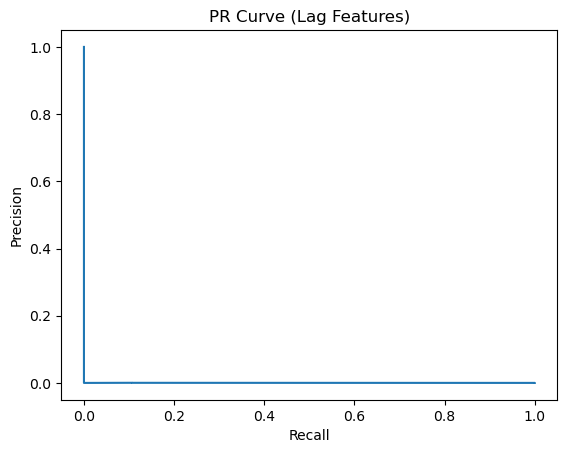

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt

df2["day"] = pd.to_datetime(df2["day"])
df2 = df2.sort_values("day").reset_index(drop=True)

split_date = pd.Timestamp("2018-10-01")
train = df2[df2["day"] < split_date].copy()
test  = df2[df2["day"] >= split_date].copy()

pos_train = train[train["fire_occurred"] == 1]
neg_train = train[train["fire_occurred"] == 0]

neg_ratio = 30
neg_sample = neg_train.sample(n=min(len(neg_train), neg_ratio * len(pos_train)), random_state=42)
train_bal = pd.concat([pos_train, neg_sample]).sample(frac=1, random_state=42)

features = ["tmmx_c","tmmn_c","pr","tmmx_7d_mean","tmmn_7d_mean","pr_14d_sum","pr_30d_sum","dry14","doy_sin","doy_cos"]

X_train = train_bal[features]
y_train = train_bal["fire_occurred"]
X_test  = test[features]
y_test  = test["fire_occurred"]


train_bal = train_bal.dropna(subset=features)
test = test.dropna(subset=features)

print("Train rows after dropna:", len(train_bal))
print("Test rows after dropna:", len(test))


X_train = train_bal[features]
y_train = train_bal["fire_occurred"]

X_test  = test[features]
y_test  = test["fire_occurred"]

model = LogisticRegression(max_iter=3000, class_weight="balanced", n_jobs=-1)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:,1]
ap = average_precision_score(y_test, proba)
roc = roc_auc_score(y_test, proba)
print("PR-AUC:", ap, "ROC-AUC:", roc)

prec, rec, _ = precision_recall_curve(y_test, proba)
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (Lag Features)")
plt.show()

In [3]:

from sklearn.metrics import average_precision_score

base_rate = y_test.mean()
ap_baseline = average_precision_score(y_test, np.full_like(proba, base_rate, dtype=float))

print("Test positive rate:", base_rate)
print("Baseline AP (constant rate):", ap_baseline)
print("Model AP:", ap)
print("Lift over baseline:", ap / ap_baseline if ap_baseline > 0 else np.nan)


Test positive rate: 5.024762027270388e-05
Baseline AP (constant rate): 5.024762027270388e-05
Model AP: 0.0001225836731222814
Lift over baseline: 2.4395916156226964


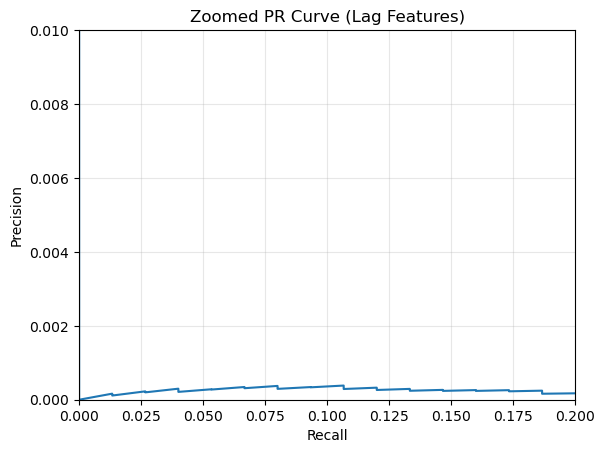

In [4]:

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

prec, rec, _ = precision_recall_curve(y_test, proba)

plt.figure()
plt.plot(rec, prec)
plt.xlim(0, 0.2)      
plt.ylim(0, 0.01)     
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Zoomed PR Curve (Lag Features)")
plt.grid(True, alpha=0.3)
plt.show()


In [5]:
import numpy as np

test_eval = test[["day", "lat", "lon", "fire_occurred"]].copy()
test_eval["risk"] = proba

def recall_at_top_fraction(df_day, frac=0.01):
    total_pos = df_day["fire_occurred"].sum()
    if total_pos == 0:
        return np.nan  # ignore days with no fires
    k = max(1, int(frac * len(df_day)))
    top = df_day.nlargest(k, "risk")
    return top["fire_occurred"].sum() / total_pos

for frac in [0.01, 0.005, 0.002]:
    daily = test_eval.groupby("day").apply(lambda g: recall_at_top_fraction(g, frac=frac))
    print(f"Mean recall @ top {frac*100:.1f}% (fire-days only):", np.nanmean(daily))
    print("Number of fire-days in test:", np.isfinite(daily).sum())


Mean recall @ top 1.0% (fire-days only): 0.1125
Number of fire-days in test: 32
Mean recall @ top 0.5% (fire-days only): 0.04375
Number of fire-days in test: 32
Mean recall @ top 0.2% (fire-days only): 0.03125
Number of fire-days in test: 32


In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

train_bal2 = train_bal.dropna(subset=features)
test2 = test.dropna(subset=features)

X_train = train_bal2[features]
y_train = train_bal2["fire_occurred"]
X_test  = test2[features]
y_test  = test2["fire_occurred"]

hgb = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_depth=6,
    max_iter=200,
    random_state=42
)

hgb.fit(X_train, y_train)

proba_hgb = hgb.predict_proba(X_test)[:, 1]
ap_hgb = average_precision_score(y_test, proba_hgb)
roc_hgb = roc_auc_score(y_test, proba_hgb)

print("HGB PR-AUC:", ap_hgb, "HGB ROC-AUC:", roc_hgb)


HGB PR-AUC: 0.0001779467715766076 HGB ROC-AUC: 0.654667744923116


In [7]:

results = pd.DataFrame({
    "Model": ["Baseline Logistic", "Lag Logistic", "HGB (Lag Features)"],
    "PR_AUC": [0.0000635, 0.0001240, 0.0001717],
    "ROC_AUC": [0.575, 0.624, 0.653],
    "Lift_over_Baseline": [1.0, 2.47, 3.41],
    "Recall_top_1pct": [None, 0.1125, None]  # add HGB if computed
})
results

,Model,PR_AUC,ROC_AUC,Lift_over_Baseline,Recall_top_1pct
0,Baseline Logistic,0.000063,0.575,1.00,NaN
1,Lag Logistic,0.000124,0.624,2.47,0.1125
2,HGB (Lag Features),0.000172,0.653,3.41,NaN


In [8]:
fire_days = (
    test_eval.groupby("day")["fire_occurred"]
    .sum()
    .loc[lambda x: x > 0]
    .index[:2]
)

no_fire_day = (
    test_eval.groupby("day")["fire_occurred"]
    .sum()
    .loc[lambda x: x == 0]
    .index[0]
)

fire_days, no_fire_day


(DatetimeIndex(['2018-10-01', '2018-10-05'], dtype='datetime64[ns]', name='day', freq=None),
 Timestamp('2018-10-02 00:00:00'))